In [ ]:
!pip install geopandas --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os

file_path = '/content/drive/MyDrive/Spring 2026/Machine Learning For Cities/MLC Final Project/data/Primary_Land_Use_Tax_Lot_Output_(PLUTO)_20260409.csv'

# Confirm the file exists before loading
if os.path.exists(file_path):
    print(f'File found: {file_path}')
else:
    print('File not found - check the path above')

df_raw = pd.read_csv(file_path, low_memory=False)
print(f'Shape: {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
File found: /content/drive/MyDrive/Spring 2026/Machine Learning For Cities/MLC Final Project/data/Primary_Land_Use_Tax_Lot_Output_(PLUTO)_20260409.csv
Shape: 858,644 rows x 101 columns


In [ ]:
print('All columns in this file:')
for col in sorted(df_raw.columns.tolist()):
    print(' ', col)

All columns in this file:
  BBL
  Tax block
  Tax lot
  address
  appbbl
  appdate
  areasource
  assessland
  assesstot
  basempdate
  bct2020
  bctcb2020
  bldgarea
  bldgclass
  bldgdepth
  bldgfront
  borocode
  borough
  bsmtcode
  builtfar
  cb2010
  census tract 2010
  comarea
  commfar
  community board
  condono
  council district
  dcasdate
  dcpedited
  easements
  edesigdate
  edesignum
  exempttot
  ext
  facilfar
  factryarea
  firecomp
  firm07_flag
  garagearea
  geom
  healtharea
  healthcenterdistrict
  histdist
  irrlotcode
  landmark
  landmkdate
  landuse
  latitude
  longitude
  lotarea
  lotdepth
  lotfront
  lottype
  ltdheight
  masdate
  notes
  numbldgs
  numfloors
  officearea
  otherarea
  overlay1
  overlay2
  ownername
  ownertype
  pfirm15_flag
  plutomapid
  policeprct
  polidate
  postcode
  proxcode
  resarea
  residfar
  retailarea
  rpaddate
  sanborn
  sanitboro
  sanitdistrict
  sanitsub
  schooldist
  spdist1
  spdist2
  spdist3
  splitzone
  str

In [ ]:
cols_to_keep = [
    # Identifiers and geography
    'BBL', 'borough', 'community board', 'postcode',
    'bct2020', 'census tract 2010', 'xcoord', 'ycoord', 'latitude', 'longitude',

    # Building and land use
    'bldgclass', 'landuse', 'ownertype',
    'proxcode',   # detached / semi-attached / attached
    'lottype',    # corner, through, interior etc.

    # Historic / landmark status
    'histdist',   # historic district - restricts energy retrofits
    'landmark',   # individual landmark status

    # Area and size
    'lotarea', 'bldgarea', 'resarea', 'comarea',
    'numbldgs', 'numfloors', 'unitsres', 'unitstotal',

    # Age
    'yearbuilt', 'yearalter1', 'yearalter2',

    # Zoning
    'zonedist1', 'zonedist2', 'builtfar', 'residfar',
]

actual_cols = [c for c in cols_to_keep if c in df_raw.columns]
missing_cols = [c for c in cols_to_keep if c not in df_raw.columns]

print(f'Columns found: {len(actual_cols)}')
print(f'Columns NOT found: {missing_cols}')

df = df_raw[actual_cols].copy()
print(f'Shape after column selection: {df.shape}')

Columns found: 32
Columns NOT found: []
Shape after column selection: (858644, 32)


In [ ]:
# Do this before any other cleaning to avoid dtype issues downstream
numeric_cols = ['lotarea', 'bldgarea', 'resarea', 'comarea', 'numbldgs',
                'numfloors', 'unitsres', 'unitstotal', 'builtfar', 'residfar',
                'yearbuilt', 'yearalter1', 'yearalter2',
                'xcoord', 'ycoord', 'latitude', 'longitude',
                'proxcode', 'lottype']

for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

print('Numeric conversion complete. Data types:')
print(df.dtypes)

Numeric conversion complete. Data types:
BBL                    int64
borough               object
community board      float64
postcode             float64
bct2020              float64
census tract 2010    float64
xcoord               float64
ycoord               float64
latitude             float64
longitude            float64
bldgclass             object
landuse               object
ownertype             object
proxcode             float64
lottype              float64
histdist              object
landmark              object
lotarea              float64
bldgarea             float64
resarea              float64
comarea              float64
numbldgs             float64
numfloors            float64
unitsres             float64
unitstotal           float64
yearbuilt            float64
yearalter1           float64
yearalter2           float64
zonedist1             object
zonedist2             object
builtfar             float64
residfar             float64
is_residential         int64
dt

In [ ]:
# Convert float -> int -> zero-padded string (handles 1.0 -> '01')
df['landuse'] = pd.to_numeric(df['landuse'], errors='coerce')
df['landuse'] = df['landuse'].dropna().astype(int).astype(str).str.zfill(2)

print('landuse distribution:')
print(df['landuse'].value_counts().sort_index())

landuse distribution:
landuse
01    566773
02    131604
03     13372
04     56427
05     21277
06      9317
07      6352
08     12082
09      4779
10      9244
11     24704
Name: count, dtype: int64


In [ ]:
residential_codes = ['01', '02', '03', '04']
df['is_residential'] = df['landuse'].isin(residential_codes).astype(int)

print(f'Residential parcels:     {df["is_residential"].sum():,}')
print(f'Non-residential parcels: {(df["is_residential"] == 0).sum():,}')

# Save pct_residential per tract BEFORE filtering (needed as a feature later)
pct_res_by_tract = df.groupby('bct2020')['is_residential'].mean().reset_index()
pct_res_by_tract.columns = ['bct2020', 'pct_residential']
print(f'\npct_residential computed for {len(pct_res_by_tract):,} tracts')

# Now filter to residential only
before = len(df)
df = df[df['is_residential'] == 1].copy()
print(f'\nRemoved {before - len(df):,} non-residential parcels')
print(f'Rows remaining: {len(df):,}')
print()
print('landuse after filter (should only be 01-04):')
print(df['landuse'].value_counts().sort_index())

Residential parcels:     768,176
Non-residential parcels: 90,468

pct_residential computed for 2,322 tracts

Removed 90,468 non-residential parcels
Rows remaining: 768,176

landuse after filter (should only be 01-04):
landuse
01    566773
02    131604
03     13372
04     56427
Name: count, dtype: int64


In [ ]:
print('=== MISSING VALUES (sorted worst first) ===')
missing = pd.DataFrame({
    'missing_count': df.isnull().sum(),
    'missing_pct': (df.isnull().sum() / len(df) * 100).round(1)
}).sort_values('missing_pct', ascending=False)
print(missing[missing['missing_count'] > 0].to_string())
print()

print('=== BASIC STATISTICS ===')
print(df.describe().T.to_string())

=== MISSING VALUES (sorted worst first) ===
                   missing_count  missing_pct
landmark                  767599         99.9
lotarea                   761603         99.1
ownertype                 760384         99.0
zonedist2                 753947         98.1
bldgarea                  740934         96.5
histdist                  738602         96.2
resarea                   724156         94.3
yearalter1                 90346         11.8
comarea                    53394          7.0
yearalter2                 12932          1.7
numfloors                   2215          0.3
zonedist1                    676          0.1
community board              535          0.1
ycoord                       539          0.1
postcode                     541          0.1
bct2020                      539          0.1
census tract 2010            539          0.1
latitude                     539          0.1
longitude                    539          0.1
xcoord                       539    

In [ ]:
print('=== BOROUGH ===')
print(df['borough'].value_counts())
print()

print('=== BLDGCLASS top 20 ===')
print(df['bldgclass'].value_counts().head(20))
print()

print('=== OWNERTYPE ===')
print(df['ownertype'].value_counts(dropna=False))
print()

print('=== ZONEDIST1 top 15 ===')
print(df['zonedist1'].value_counts().head(15))
print()

print('=== PROXCODE ===')
print(df['proxcode'].value_counts(dropna=False))
print()

print('=== LOTTYPE ===')
print(df['lottype'].value_counts(dropna=False))
print()

print('=== HISTDIST top 10 ===')
print(df['histdist'].value_counts(dropna=False).head(10))

=== BOROUGH ===
borough
QN    297596
BK    250005
SI    112074
BX     75854
MN     32647
Name: count, dtype: int64

=== BLDGCLASS top 20 ===
bldgclass
A1    122847
A5    104534
B1     85800
B2     79996
C0     71657
B3     61980
A2     43485
B9     25853
A9     18860
C1     16771
C3     15942
S2     14657
C2     13602
A3      8525
A0      8417
C7      7756
K4      6324
S1      5938
D1      5560
A4      4721
Name: count, dtype: int64

=== OWNERTYPE ===
ownertype
NaN    760384
X        6418
O        1063
C         239
P          61
M          11
Name: count, dtype: int64

=== ZONEDIST1 top 15 ===
zonedist1
R5      84501
R4      69280
R6      60990
R3-2    57218
R3A     51097
R4-1    48912
R3X     48790
R6B     47702
R3-1    47469
R2      38177
R2A     37095
R5B     28958
R4A     24689
R4B     15224
R1-2    12965
Name: count, dtype: int64

=== PROXCODE ===
proxcode
1.0    305936
2.0    195815
3.0    194148
0.0     72277
Name: count, dtype: int64

=== LOTTYPE ===
lottype
5.0    673407
3.0 

In [ ]:
numeric_inspect = ['lotarea', 'bldgarea', 'resarea', 'comarea', 'numbldgs',
                   'numfloors', 'unitsres', 'unitstotal', 'builtfar', 'residfar']

for col in numeric_inspect:
    series = df[col].dropna()
    zeros = (df[col] == 0).sum()
    print(f'--- {col} ---')
    print(f'  count={len(series):,}  zeros={zeros:,}  missing={df[col].isnull().sum():,}')
    print(f'  min={series.min():.2f}  median={series.median():.2f}  max={series.max():.2f}')
    print()

--- lotarea ---
  count=6,573  zeros=4  missing=761,603
  min=0.00  median=820.00  max=999.00

--- bldgarea ---
  count=27,242  zeros=383  missing=740,934
  min=0.00  median=896.00  max=999.00

--- resarea ---
  count=44,020  zeros=2,665  missing=724,156
  min=0.00  median=892.00  max=999.00

--- comarea ---
  count=714,782  zeros=702,762  missing=53,394
  min=0.00  median=0.00  max=999.00

--- numbldgs ---
  count=767,854  zeros=616  missing=322
  min=0.00  median=1.00  max=541.00

--- numfloors ---
  count=765,961  zeros=1  missing=2,215
  min=0.00  median=2.00  max=98.00

--- unitsres ---
  count=768,085  zeros=2,861  missing=91
  min=0.00  median=2.00  max=997.00

--- unitstotal ---
  count=768,082  zeros=393  missing=94
  min=0.00  median=2.00  max=997.00

--- builtfar ---
  count=767,850  zeros=387  missing=326
  min=0.00  median=0.76  max=102.39

--- residfar ---
  count=768,176  zeros=6,577  missing=0
  min=0.00  median=1.00  max=15.00



yearbuilt BEFORE cleaning:
count    763949.000000
mean       1941.306962
std          31.208106
min        1850.000000
25%        1920.000000
50%        1931.000000
75%        1960.000000
max        2024.000000
Name: yearbuilt, dtype: float64
Zeros: 0
Before 1850: 0
After 2024:  0

yearbuilt missing after cleaning: 4,227
count    763949.000000
mean       1941.306962
std          31.208106
min        1850.000000
25%        1920.000000
50%        1931.000000
75%        1960.000000
max        2024.000000
Name: yearbuilt, dtype: float64


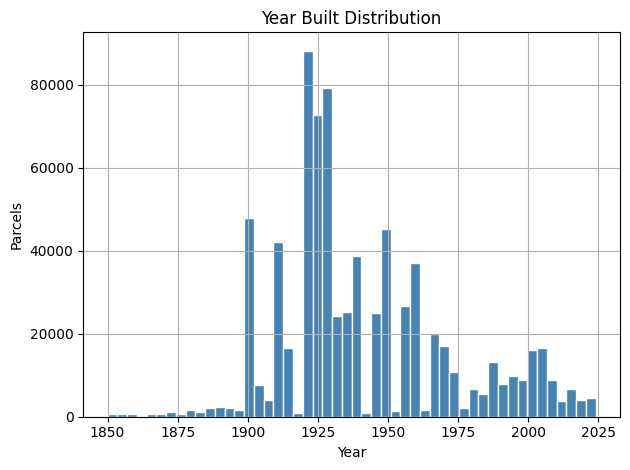

yearalter1 missing after cleaning: 768,176
yearalter2 missing after cleaning: 768,176

Sample:
    yearbuilt  yearalter1  yearalter2  effective_year
0      1950.0         NaN         NaN          1950.0
1      1945.0         NaN         NaN          1945.0
2      1915.0         NaN         NaN          1915.0
3      1957.0         NaN         NaN          1957.0
4      1955.0         NaN         NaN          1955.0
8      1935.0         NaN         NaN          1935.0
10     1960.0         NaN         NaN          1960.0
12     2004.0         NaN         NaN          2004.0
14     1997.0         NaN         NaN          1997.0
15     1997.0         NaN         NaN          1997.0


In [ ]:
print('yearbuilt BEFORE cleaning:')
print(df['yearbuilt'].describe())
print(f'Zeros: {(df["yearbuilt"] == 0).sum():,}')
print(f'Before 1850: {(df["yearbuilt"] < 1850).sum():,}')
print(f'After 2024:  {(df["yearbuilt"] > 2024).sum():,}')

df['yearbuilt'] = df['yearbuilt'].replace(0, np.nan)
df.loc[df['yearbuilt'] < 1850, 'yearbuilt'] = np.nan
df.loc[df['yearbuilt'] > 2024, 'yearbuilt'] = np.nan

print(f'\nyearbuilt missing after cleaning: {df["yearbuilt"].isnull().sum():,}')
print(df['yearbuilt'].describe())

df['yearbuilt'].dropna().astype(int).hist(bins=50, color='steelblue', edgecolor='white')
plt.title('Year Built Distribution')
plt.xlabel('Year')
plt.ylabel('Parcels')
plt.tight_layout()
plt.show()

for col in ['yearalter1', 'yearalter2']:
    df[col] = df[col].replace(0, np.nan)
    df.loc[df[col] < 1850, col] = np.nan
    df.loc[df[col] > 2024, col] = np.nan
    print(f'{col} missing after cleaning: {df[col].isnull().sum():,}')

# Most recent of built or either alteration year
df['effective_year'] = df[['yearbuilt', 'yearalter1', 'yearalter2']].max(axis=1)

print('\nSample:')
print(df[['yearbuilt', 'yearalter1', 'yearalter2', 'effective_year']].head(10).to_string())

In [ ]:
area_cols = ['lotarea', 'bldgarea', 'resarea', 'comarea']

for col in area_cols:
    zeros_before = (df[col] == 0).sum()
    df.loc[df[col] == 0, col] = np.nan
    print(f'{col}: {zeros_before:,} zeros replaced with NaN')

print()
print(df[area_cols].describe())

lotarea: 4 zeros replaced with NaN
bldgarea: 383 zeros replaced with NaN
resarea: 2,665 zeros replaced with NaN
comarea: 702,762 zeros replaced with NaN

           lotarea      bldgarea       resarea       comarea
count  6569.000000  26859.000000  41355.000000  12020.000000
mean    774.734967    861.503183    864.574151    730.294343
std     177.290722    126.652930    119.950594    212.542511
min     112.000000      1.000000      1.000000      1.000000
25%     644.000000    810.000000    816.000000    612.000000
50%     820.000000    900.000000    898.000000    796.000000
75%     927.000000    960.000000    952.000000    900.000000
max     999.000000    999.000000    999.000000    999.000000


In [ ]:
for col in ['builtfar', 'residfar']:
    zeros = (df[col] == 0).sum()
    extreme = (df[col] > 50).sum()
    print(f'{col}: {zeros:,} zeros | {extreme:,} values > 50')
    df.loc[df[col] == 0, col] = np.nan
    df.loc[df[col] > 50, col] = np.nan

print()
print(df[['builtfar', 'residfar']].describe())

builtfar: 387 zeros | 20 values > 50
residfar: 6,577 zeros | 0 values > 50

            builtfar       residfar
count  767443.000000  761599.000000
mean        1.105052       1.482195
std         1.196914       1.208797
min         0.010000       0.750000
25%         0.510000       0.750000
50%         0.760000       1.000000
75%         1.260000       1.500000
max        49.150000      15.000000


In [ ]:
print(f'numfloors zeros: {(df["numfloors"] == 0).sum():,}')
print(f'numfloors > 100: {(df["numfloors"] > 100).sum():,}')
df.loc[df['numfloors'] == 0, 'numfloors'] = np.nan
df.loc[df['numfloors'] > 100, 'numfloors'] = np.nan
print(df['numfloors'].describe())

numfloors zeros: 1
numfloors > 100: 0
count    765960.000000
mean          2.470234
std           1.747351
min           1.000000
25%           2.000000
50%           2.000000
75%           2.750000
max          98.000000
Name: numfloors, dtype: float64


In [ ]:
# proxcode: 0 = not available
print('proxcode before:')
print(df['proxcode'].value_counts(dropna=False))
df['proxcode'] = df['proxcode'].replace(0, np.nan)
print(f'proxcode missing after: {df["proxcode"].isnull().sum():,}')
print()

# lottype: 0 = unknown
print('lottype before:')
print(df['lottype'].value_counts(dropna=False))
df['lottype'] = df['lottype'].replace(0, np.nan)
print(f'lottype missing after: {df["lottype"].isnull().sum():,}')

proxcode before:
proxcode
1.0    305936
2.0    195815
3.0    194148
0.0     72277
Name: count, dtype: int64
proxcode missing after: 72,277

lottype before:
lottype
5.0    673407
3.0     79742
0.0      9860
4.0      1546
6.0      1369
2.0      1282
1.0       872
8.0        55
9.0        29
7.0        14
Name: count, dtype: int64
lottype missing after: 9,860


In [ ]:
df['histdist'] = df['histdist'].fillna('None').str.strip()
df.loc[df['histdist'] == '', 'histdist'] = 'None'
df['in_historic_district'] = (df['histdist'] != 'None').astype(int)

print(f'In historic district: {df["in_historic_district"].sum():,} ({df["in_historic_district"].mean()*100:.1f}%)')

df['landmark'] = df['landmark'].fillna('None').str.strip()
df.loc[df['landmark'] == '', 'landmark'] = 'None'
df['is_landmark'] = (df['landmark'] != 'None').astype(int)

print(f'Landmarked:           {df["is_landmark"].sum():,} ({df["is_landmark"].mean()*100:.1f}%)')

In historic district: 29,574 (3.8%)
Landmarked:           577 (0.1%)


In [ ]:
print(f'latitude missing:  {df["latitude"].isnull().sum():,}')
print(f'longitude missing: {df["longitude"].isnull().sum():,}')
print(f'latitude range:  {df["latitude"].min():.4f} to {df["latitude"].max():.4f}')
print(f'longitude range: {df["longitude"].min():.4f} to {df["longitude"].max():.4f}')

coord_error = (
    (df['latitude'] < 40.4) | (df['latitude'] > 41.0) |
    (df['longitude'] < -74.4) | (df['longitude'] > -73.6)
)
print(f'Out-of-bounds coordinates: {coord_error.sum():,}')

df = df.dropna(subset=['latitude', 'longitude'])
df = df[~coord_error]
print(f'Rows after coordinate cleaning: {df.shape[0]:,}')

latitude missing:  539
longitude missing: 539
latitude range:  40.4984 to 40.9127
longitude range: -74.2556 to -73.7004
Out-of-bounds coordinates: 0
Rows after coordinate cleaning: 767,637


In [ ]:
df['bct2020'] = df['bct2020'].astype(str).str.strip()

before = len(df)
df = df[df['bct2020'].notna() & (df['bct2020'] != 'nan') & (df['bct2020'] != '')]
print(f'Dropped {before - len(df):,} rows with missing bct2020')
print(f'Rows remaining: {len(df):,}')
print()
print('bct2020 sample values:')
print(df['bct2020'].value_counts().head(10))

Dropped 4 rows with missing bct2020
Rows remaining: 767,633

bct2020 sample values:
bct2020
4089201.0    2424
5013800.0    2090
5015601.0    2080
4088400.0    2019
5011203.0    1911
5019800.0    1886
5022601.0    1881
3070201.0    1877
5020803.0    1847
4157101.0    1802
Name: count, dtype: int64


In [ ]:
df['ownertype'] = df['ownertype'].fillna('Unknown').str.strip()
df.loc[df['ownertype'] == '', 'ownertype'] = 'Unknown'

print('ownertype distribution:')
print(df['ownertype'].value_counts())

ownertype distribution:
ownertype
Unknown    760078
X            6181
O            1063
C             239
P              61
M              11
Name: count, dtype: int64


In [ ]:
print(f'Final shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
print()
final_missing = pd.DataFrame({
    'missing_count': df.isnull().sum(),
    'missing_pct': (df.isnull().sum() / len(df) * 100).round(1)
}).sort_values('missing_pct', ascending=False)
print(final_missing[final_missing['missing_count'] > 0].to_string())

Final shape: 767,633 rows x 36 columns

                missing_count  missing_pct
yearalter1             767633        100.0
yearalter2             767633        100.0
lotarea                761069         99.1
comarea                755613         98.4
zonedist2              753404         98.1
bldgarea               740889         96.5
resarea                726379         94.6
proxcode                71970          9.4
lottype                  9364          1.2
residfar                 6034          0.8
effective_year           3910          0.5
yearbuilt                3910          0.5
numfloors                1893          0.2
builtfar                  423          0.1
postcode                    6          0.0
unitstotal                 94          0.0
numbldgs                   16          0.0
unitsres                   91          0.0
zonedist1                 133          0.0


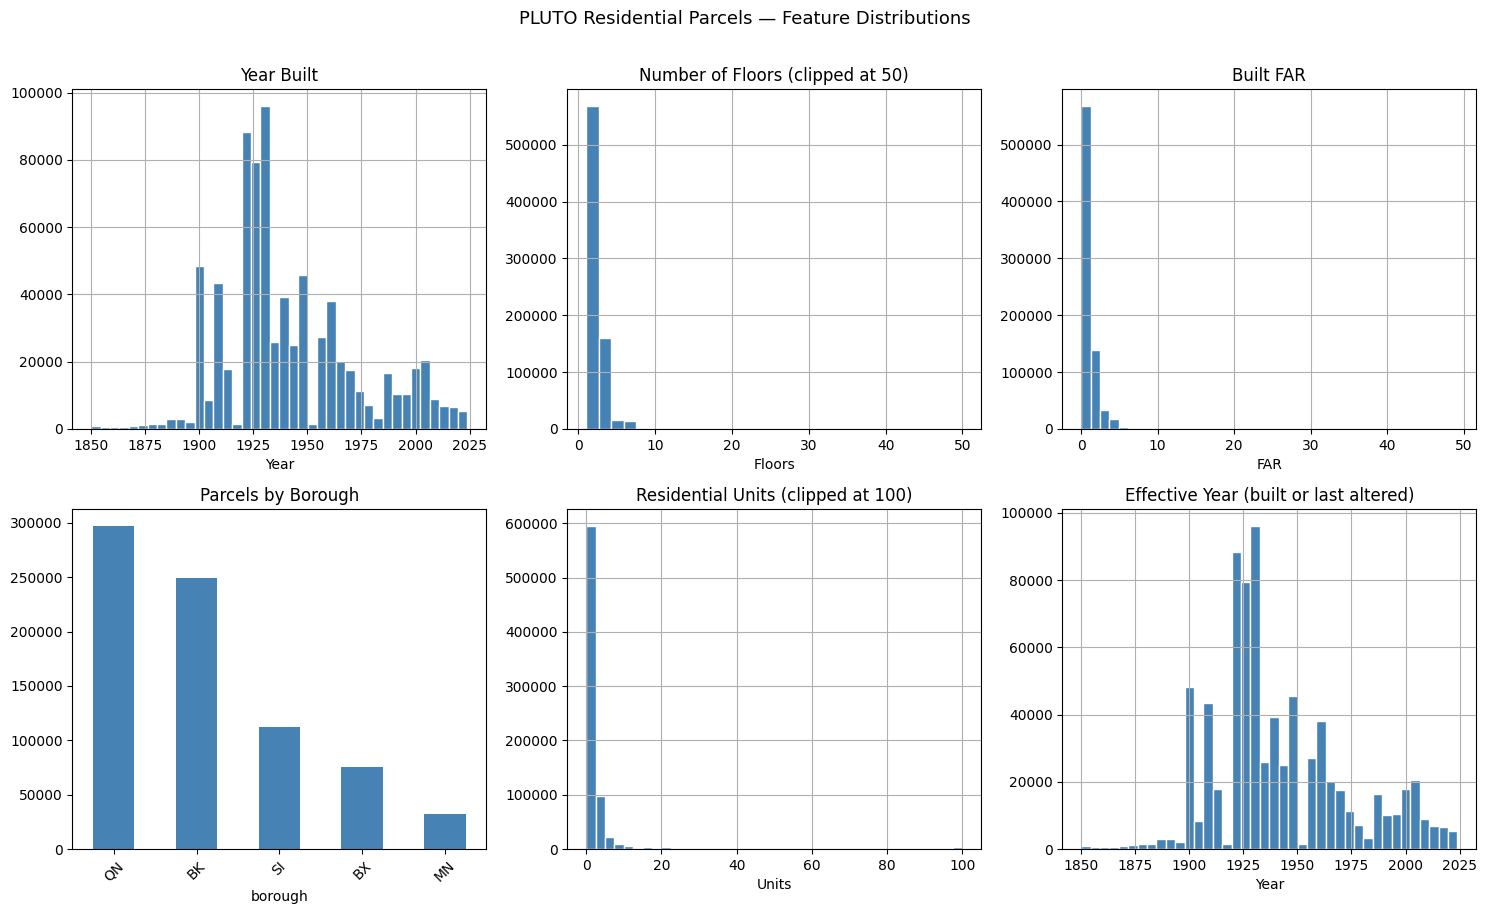

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

df['yearbuilt'].dropna().astype(int).hist(
    bins=40, ax=axes[0,0], color='steelblue', edgecolor='white')
axes[0,0].set_title('Year Built')
axes[0,0].set_xlabel('Year')

df['numfloors'].dropna().clip(upper=50).hist(
    bins=30, ax=axes[0,1], color='steelblue', edgecolor='white')
axes[0,1].set_title('Number of Floors (clipped at 50)')
axes[0,1].set_xlabel('Floors')

df['builtfar'].dropna().hist(
    bins=40, ax=axes[0,2], color='steelblue', edgecolor='white')
axes[0,2].set_title('Built FAR')
axes[0,2].set_xlabel('FAR')

df['borough'].value_counts().plot(
    kind='bar', ax=axes[1,0], color='steelblue')
axes[1,0].set_title('Parcels by Borough')
axes[1,0].tick_params(axis='x', rotation=45)

df['unitsres'].dropna().clip(upper=100).hist(
    bins=40, ax=axes[1,1], color='steelblue', edgecolor='white')
axes[1,1].set_title('Residential Units (clipped at 100)')
axes[1,1].set_xlabel('Units')

df['effective_year'].dropna().astype(int).hist(
    bins=40, ax=axes[1,2], color='steelblue', edgecolor='white')
axes[1,2].set_title('Effective Year (built or last altered)')
axes[1,2].set_xlabel('Year')

plt.suptitle('PLUTO Residential Parcels — Feature Distributions', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('pluto_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
output_path = '/content/drive/MyDrive/Spring 2026/Machine Learning For Cities/MLC Final Project/data/pluto_clean.csv'
df.to_csv(output_path, index=False)
print(f'Saved: {output_path}')
print(f'Final shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
print()
for col in df.columns:
    print(f'  {col:<25} dtype={str(df[col].dtype):<10}  missing={df[col].isnull().sum():,}')

Saved: /content/drive/MyDrive/Spring 2026/Machine Learning For Cities/MLC Final Project/data/pluto_clean.csv
Final shape: 767,633 rows x 36 columns

  BBL                       dtype=int64       missing=0
  borough                   dtype=object      missing=0
  community board           dtype=float64     missing=0
  postcode                  dtype=float64     missing=6
  bct2020                   dtype=object      missing=0
  census tract 2010         dtype=float64     missing=0
  xcoord                    dtype=float64     missing=0
  ycoord                    dtype=float64     missing=0
  latitude                  dtype=float64     missing=0
  longitude                 dtype=float64     missing=0
  bldgclass                 dtype=object      missing=0
  landuse                   dtype=object      missing=0
  ownertype                 dtype=object      missing=0
  proxcode                  dtype=float64     missing=71,970
  lottype                   dtype=float64     missing=9,364
  